# Model Validation — Reported Urban Pressure

This notebook validates the Bayesian 311 model as a **reported urban pressure model**, not a direct ground-truth quality-of-life model.

The goal is to check:

1. Did the model sample correctly?
2. Can it reproduce observed complaint counts?
3. Are uncertainty intervals calibrated?
4. Where does the model over/under-predict?
5. Does the model outperform simple baselines?
6. Are the dashboard-ready outputs sensible?

In [1]:
import re
import sys
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    sys.path.insert(0, str(cwd.parent))
else:
    sys.path.insert(0, str(cwd))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pymc as pm
import arviz as az

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

/Users/mozilla/Library/Caches/pypoetry/virtualenvs/municipal-stress-engine-d7i9H-rK-py3.12/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [3]:
from helpers import prep_the_data, prep_zone_data, load_idata

## 1. Load model outputs

This assumes your saved model inference data is stored as NetCDF.

Expected useful groups:

- `posterior`
- `sample_stats`
- optionally `posterior_predictive`
- optionally `observed_data`

In [5]:
IDATA_PATH = "../data/processed/models/model_urban_pressure_idata.nc"

idata = load_idata(IDATA_PATH)
idata

✅ Loaded idata <- ../data/processed/models/model_urban_pressure_idata.nc


Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
	> constant_data

In [6]:
print(idata)
print("Groups:", idata.groups())
print("Posterior variables:")
print(list(idata.posterior.data_vars))

if hasattr(idata, "sample_stats"):
    print("Sample stats variables:")
    print(list(idata.sample_stats.data_vars))

if hasattr(idata, "posterior_predictive"):
    print("Posterior predictive variables:")
    print(list(idata.posterior_predictive.data_vars))

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
	> constant_data
Groups: ['posterior', 'log_likelihood', 'sample_stats', 'observed_data', 'constant_data']
Posterior variables:
['beta0', 'beta_issue', 'beta_reporting', 'alpha_nta', 'gamma_month', 'delta_cat', 'beta_sin', 'beta_cos', 'sigma_nta', 'sigma_month', 'sigma_cat', 'alpha_nb_cat', 'issue_structural', 'mu']
Sample stats variables:
['perf_counter_start', 'acceptance_rate', 'diverging', 'energy_error', 'smallest_eigval', 'lp', 'reached_max_treedepth', 'tree_depth', 'largest_eigval', 'max_energy_error', 'step_size_bar', 'index_in_trajectory', 'step_size', 'process_time_diff', 'energy', 'n_steps', 'perf_counter_diff', 'divergences']


## 2. Sampling diagnostics

Before trusting any score, trend, or dashboard output, check whether the MCMC run is reliable.

Key checks:

- `r_hat` close to 1.00
- adequate effective sample size
- no meaningful divergence problem
- no obvious trace pathologies

In [7]:
DIAG_VARS = [
    v for v in [
        "beta0",
        "beta_issue",
        "beta_reporting",
        "sigma_nta",
        "sigma_week",
        "sigma_cat",
        "sigma_state",
        "alpha_nb",
        "rho",
    ]
    if v in idata.posterior.data_vars
]

az.summary(idata, var_names=DIAG_VARS, round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,-7.139,0.234,-7.559,-6.716,0.025,0.009,86.827,312.496,1.035
beta_issue[res_units_per_acre],-0.031,0.112,-0.240,0.174,0.006,0.003,327.158,743.852,1.008
beta_issue[bldg_sqft_per_acre],-0.212,0.184,-0.560,0.135,0.008,0.004,522.589,1036.853,1.006
beta_issue[buildings_per_acre],-0.010,0.093,-0.184,0.165,0.007,0.004,179.870,283.231,1.020
beta_issue[pct_res_area],-0.781,0.106,-0.968,-0.575,0.005,0.003,372.500,660.511,1.009
beta_issue[pct_com_area],0.628,0.092,0.453,0.787,0.004,0.002,437.616,648.851,1.002
beta_issue[pct_mixed_use_lots],-0.044,0.090,-0.202,0.139,0.006,0.003,227.469,446.404,1.017
beta_issue[pct_prewar],0.123,0.077,-0.022,0.268,0.007,0.004,138.710,127.530,1.021
beta_issue[avg_built_far_weighted],-0.079,0.163,-0.393,0.216,0.007,0.004,623.580,957.740,1.004
beta_issue[zoning_share__Commercial],-0.574,0.117,-0.813,-0.369,0.004,0.003,768.105,1038.615,1.004


In [8]:
# Divergence check
if hasattr(idata, "sample_stats") and "diverging" in idata.sample_stats:
    n_div = int(idata.sample_stats["diverging"].sum().values)
    n_draws = int(np.prod(idata.sample_stats["diverging"].shape))
    print(f"Divergences: {n_div} / {n_draws} ({n_div / n_draws:.2%})")
else:
    print("No divergence field found in idata.sample_stats.")

# Basic sampler health fields, if available
for field in ["acceptance_rate", "step_size", "tree_depth", "energy"]:
    if hasattr(idata, "sample_stats") and field in idata.sample_stats:
        vals = idata.sample_stats[field].values.ravel()
        print(f"{field}: mean={np.nanmean(vals):.4f}, min={np.nanmin(vals):.4f}, max={np.nanmax(vals):.4f}")

Divergences: 0 / 2000 (0.00%)
acceptance_rate: mean=0.8504, min=0.2720, max=1.0000
step_size: mean=0.0063, min=0.0052, max=0.0068
tree_depth: mean=9.7460, min=9.0000, max=10.0000
energy: mean=1029970.9237, min=1029901.8131, max=1030037.8811


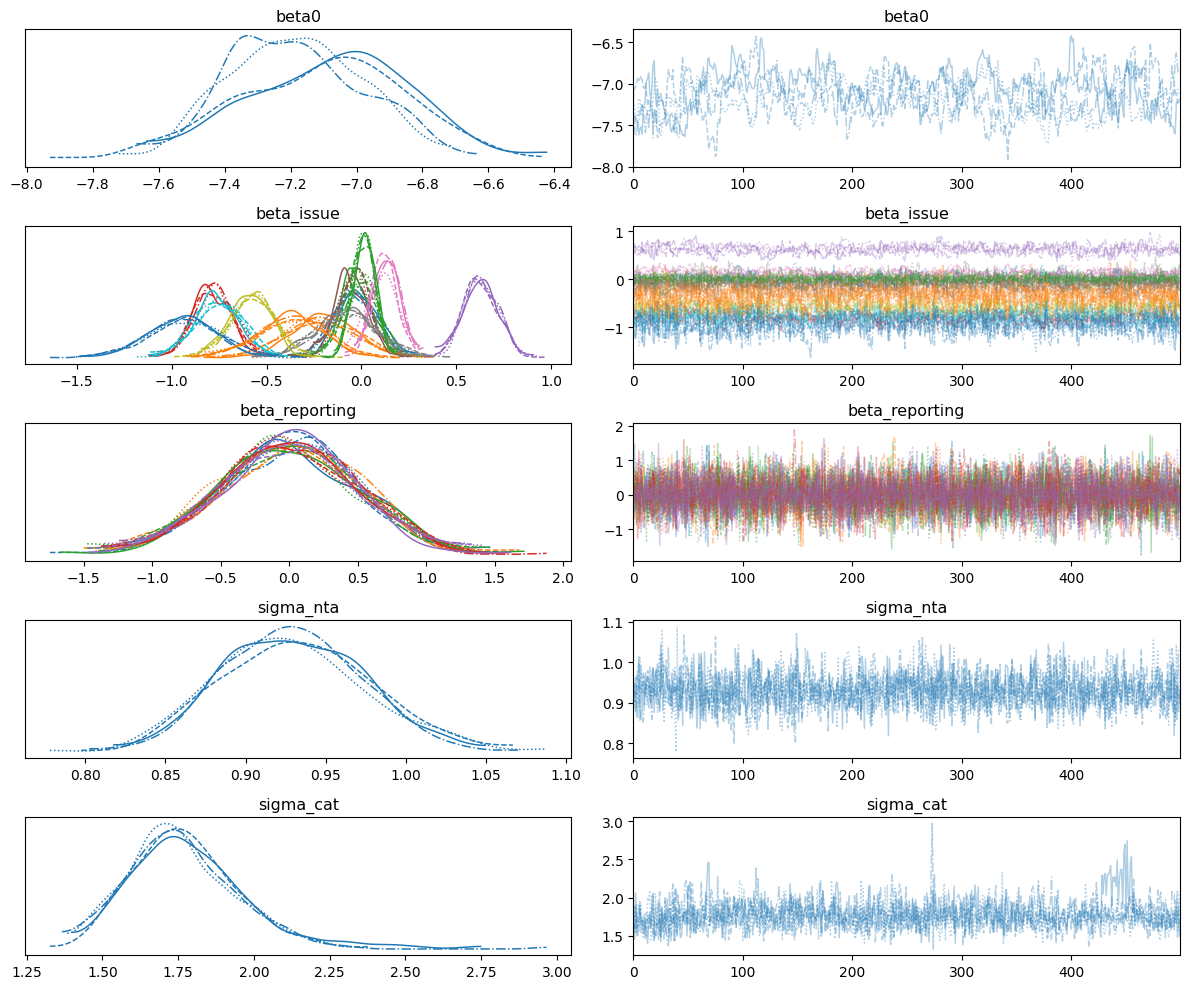

In [9]:
if DIAG_VARS:
    az.plot_trace(idata, var_names=DIAG_VARS[:6], compact=True)
    plt.tight_layout()
else:
    print("No diagnostic variables found for trace plotting.")

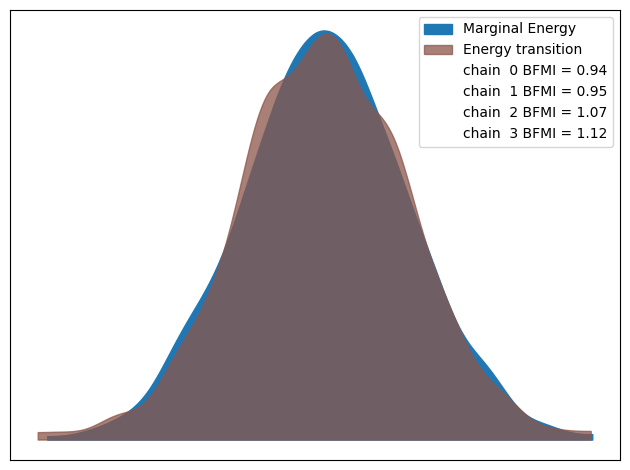

In [10]:
if hasattr(idata, "sample_stats") and "energy" in idata.sample_stats:
    az.plot_energy(idata)
    plt.tight_layout()
else:
    print("No energy field found for energy plot.")

## 3. Load and align validation dataframe

You need the model input dataframe used to create `y`, `nta_idx`, `week_idx`, `cat_idx`, and exposure.

The dataframe should ideally contain:

- observed count column, for example `complaint_count`
- NTA identifier, for example `nta_id`
- week identifier/date, for example `week_start`
- category, for example `level_2`, `category`, or `complaint_category`
- exposure column

Update the cell below if your `prep_the_data()` signature differs.

In [11]:
df_nta = pd.read_parquet("../data/processed/features/complaints_311_nta_category.parquet")
prepared = prep_the_data(df_nta)
df_nta['complaint_date'] = pd.to_datetime(df_nta['complaint_date'], errors='coerce')


cutoff = pd.Timestamp("2024-12-31")

prepared_filtered = df_nta[df_nta['complaint_date'] <= cutoff]

In [12]:
# Build validation rows on the exact model observation grid (nta x month x category)
# to guarantee alignment with posterior 'obs' ordering.

if "month" not in idata.posterior.coords:
    raise KeyError("Expected 'month' coordinate in idata.posterior.")

nta_vals = pd.Index(idata.posterior.coords["nta"].values, name="nta_id")
month_vals = pd.to_datetime(pd.Index(idata.posterior.coords["month"].values, name="month_start"))
cat_vals = pd.Index(idata.posterior.coords["category"].values, name="level_2")

obs_monthly = (
    prepared_filtered.assign(month_start=lambda d: d["complaint_date"].dt.to_period("M").dt.start_time)
    .groupby(["nta_id", "month_start", "level_2"], observed=True)["complaint_count"]
    .sum()
    .reset_index(name="complaint_count")
)

model_grid = pd.MultiIndex.from_product(
    [nta_vals, month_vals, cat_vals],
    names=["nta_id", "month_start", "level_2"],
).to_frame(index=False)

model_df = model_grid.merge(
    obs_monthly,
    on=["nta_id", "month_start", "level_2"],
    how="left",
)
model_df["complaint_count"] = model_df["complaint_count"].fillna(0.0)

print(model_df.shape)
display(model_df.head())

(561600, 4)


,nta_id,month_start,level_2,complaint_count
0,BK0101,2022-01-01,Animal Welfare,0.0
1,BK0101,2022-01-01,Domestic Animals,0.0
2,BK0101,2022-01-01,Insects,0.0
3,BK0101,2022-01-01,Rodents,13.0
4,BK0101,2022-01-01,Wildlife & Other Animal Issues,0.0


In [13]:
def infer_column(df, candidates, required=True):
    """Return the first matching column from candidates."""
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Could not infer column. Tried: {candidates}")
    return None

if model_df is not None:
    y_col = infer_column(model_df, ["complaint_count", "count", "y", "n_complaints"])
    nta_col = infer_column(model_df, ["nta_id", "nta", "nta_name", "NTAName"], required=False)
    week_col = infer_column(model_df, ["month_start", "week_start", "week", "date", "complaint_week"], required=False)
    cat_col = infer_column(model_df, ["level_2", "category", "complaint_type", "complaint_category"], required=False)
    exposure_col = infer_column(model_df, ["exposure", "population", "housing_units", "households"], required=False)

    print({
        "y_col": y_col,
        "nta_col": nta_col,
        "week_col": week_col,
        "cat_col": cat_col,
        "exposure_col": exposure_col,
    })
else:
    print("Load model_df first.")

{'y_col': 'complaint_count', 'nta_col': 'nta_id', 'week_col': 'month_start', 'cat_col': 'level_2', 'exposure_col': None}


## 4. Extract posterior expected counts

The model stores `mu`, the posterior expected complaint count for each observation.

This section creates:

- posterior mean prediction
- residuals
- actual / predicted ratio
- log ratio, useful for pressure-style scoring

In [14]:
def posterior_obs_samples(idata, var_name):
    """
    Return samples as an array with shape (obs, samples) for a posterior variable.
    Assumes variable has an obs dimension plus chain/draw.
    """
    arr = idata.posterior[var_name]
    stacked = arr.stack(sample=("chain", "draw"))

    if "obs" in stacked.dims:
        return stacked.transpose("obs", "sample").values

    # Fallback: find first non-sample dim and treat it as observation.
    obs_dims = [d for d in stacked.dims if d != "sample"]
    if len(obs_dims) != 1:
        raise ValueError(f"Cannot infer obs dimension for {var_name}. Dims: {stacked.dims}")
    return stacked.transpose(obs_dims[0], "sample").values

if "mu" not in idata.posterior.data_vars:
    raise KeyError("Expected posterior variable 'mu' not found. Make sure the model saves pm.Deterministic('mu', ...).")

mu_samples = posterior_obs_samples(idata, "mu")
mu_mean = mu_samples.mean(axis=1)
mu_median = np.median(mu_samples, axis=1)
mu_p10 = np.percentile(mu_samples, 10, axis=1)
mu_p90 = np.percentile(mu_samples, 90, axis=1)

print("mu_samples shape:", mu_samples.shape)

mu_samples shape: (561600, 2000)


In [15]:
if model_df is not None:
    if len(model_df) != len(mu_mean):
        print(f"WARNING: model_df rows ({len(model_df)}) != posterior obs ({len(mu_mean)}). Check alignment before trusting results.")
    else:
        val_df = model_df.copy()
        val_df["y_obs"] = val_df[y_col].astype(float)
        val_df["mu_mean"] = mu_mean
        val_df["mu_median"] = mu_median
        val_df["mu_p10"] = mu_p10
        val_df["mu_p90"] = mu_p90
        val_df["residual"] = val_df["y_obs"] - val_df["mu_mean"]
        val_df["abs_error"] = val_df["residual"].abs()
        val_df["pressure_ratio"] = val_df["y_obs"] / (val_df["mu_mean"] + 1e-9)
        val_df["log_pressure_ratio"] = np.log1p(val_df["y_obs"]) - np.log1p(val_df["mu_mean"])
        display(val_df.head())
else:
    val_df = None
    print("Load model_df first.")

,nta_id,month_start,level_2,complaint_count,y_obs,mu_mean,mu_median,mu_p10,mu_p90,residual,abs_error,pressure_ratio,log_pressure_ratio
0,BK0101,2022-01-01,Animal Welfare,0.0,0.0,3.376728,3.375025,3.252335,3.503055,-3.376728,3.376728,0.000000,-1.476301
1,BK0101,2022-01-01,Domestic Animals,0.0,0.0,0.267305,0.267523,0.254373,0.280269,-0.267305,0.267305,0.000000,-0.236893
2,BK0101,2022-01-01,Insects,0.0,0.0,0.172262,0.172163,0.160336,0.184536,-0.172262,0.172262,0.000000,-0.158935
3,BK0101,2022-01-01,Rodents,13.0,13.0,10.430719,10.423564,10.061123,10.803035,2.569281,2.569281,1.246319,0.202753
4,BK0101,2022-01-01,Wildlife & Other Animal Issues,0.0,0.0,0.318561,0.318546,0.302031,0.334680,-0.318561,0.318561,0.000000,-0.276541


## 5. Actual vs predicted checks

These plots answer:

- Does the model predict the right scale of complaints?
- Is it systematically underpredicting high-count observations?
- Are errors concentrated in certain categories, NTAs, or weeks?

In [16]:
if val_df is not None:
    mae = val_df["abs_error"].mean()
    rmse = np.sqrt(np.mean(val_df["residual"] ** 2))
    bias = val_df["residual"].mean()

    print(f"MAE:  {mae:,.3f}")
    print(f"RMSE: {rmse:,.3f}")
    print(f"Bias: {bias:,.3f}")

MAE:  6.484
RMSE: 48.066
Bias: -0.190


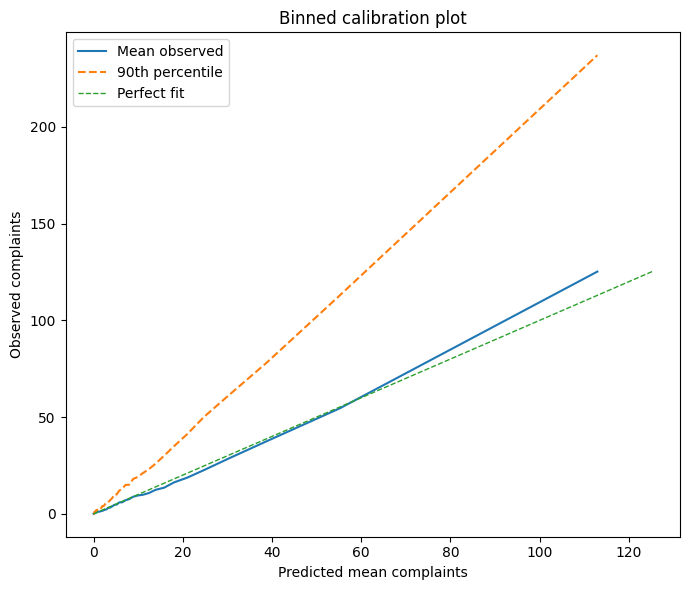

In [17]:
if val_df is not None:
    df = val_df.copy()

    # Bin predictions
    df["bin"] = pd.qcut(df["mu_mean"], q=50, duplicates="drop")

    grouped = df.groupby("bin").agg(
        pred_mean=("mu_mean", "mean"),
        obs_mean=("y_obs", "mean"),
        obs_p90=("y_obs", lambda x: np.percentile(x, 90)),
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(grouped["pred_mean"], grouped["obs_mean"], label="Mean observed")
    ax.plot(grouped["pred_mean"], grouped["obs_p90"], linestyle="--", label="90th percentile")

    lim = max(grouped["pred_mean"].max(), grouped["obs_mean"].max())
    ax.plot([0, lim], [0, lim], linestyle="--", linewidth=1, label="Perfect fit")

    ax.set_xlabel("Predicted mean complaints")
    ax.set_ylabel("Observed complaints")
    ax.set_title("Binned calibration plot")

    ax.legend()
    plt.tight_layout()

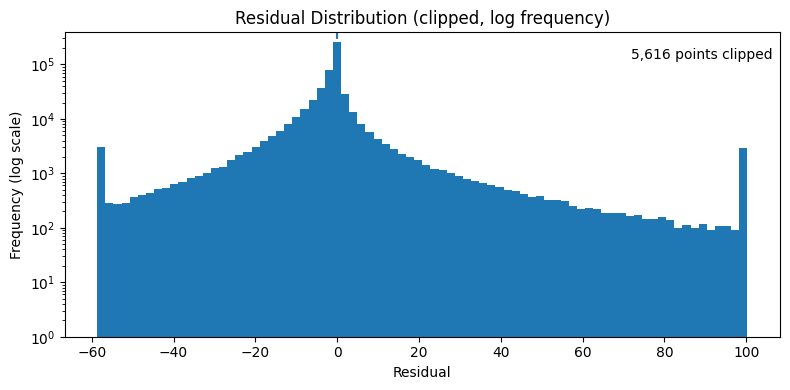

In [18]:
if val_df is not None:
    res = val_df["residual"]

    # Clip for visualization only
    lower, upper = np.percentile(res, [0.5, 99.5])
    res_clipped = res.clip(lower, upper)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(res_clipped, bins=80)
    ax.axvline(0, linestyle="--")

    ax.set_yscale("log")
    ax.set_ylim(bottom=1)

    ax.set_title("Residual Distribution (clipped, log frequency)")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency (log scale)")

    n_clipped = ((res < lower) | (res > upper)).sum()
    ax.text(
        0.99, 0.95,
        f"{n_clipped:,} points clipped",
        transform=ax.transAxes,
        ha="right",
        va="top"
    )

    plt.tight_layout()
else:
    print("Create val_df first.")

In [19]:
if val_df is not None and cat_col is not None:
    by_cat = (
        val_df.groupby(cat_col, observed=True)
        .agg(
            n=("y_obs", "size"),
            observed_total=("y_obs", "sum"),
            predicted_total=("mu_mean", "sum"),
            mae=("abs_error", "mean"),
            bias=("residual", "mean"),
        )
        .assign(total_ratio=lambda d: d["observed_total"] / (d["predicted_total"] + 1e-9))
        .sort_values("mae", ascending=False)
    )
    display(by_cat.head(25))
else:
    print("Need val_df and category column.")

,n,observed_total,predicted_total,mae,bias,total_ratio
level_2,,,,,,
Parking Issues,9360,698511.0,705013.543599,39.309263,-0.694716,0.990777
Heat & Hot Water,9360,335857.0,329988.783712,37.429736,0.626946,1.017783
Residential Noise,9360,627261.0,505046.263900,36.485103,13.057130,1.241987
Traffic & Vehicle Noise,9360,405024.0,348061.445040,31.138931,6.085743,1.163657
Blocked Access,9360,250754.0,255528.939780,19.013442,-0.510143,0.981314
Building Systems,9360,193503.0,174000.399450,13.782980,2.083611,1.112084
Abandoned Vehicles,9360,157012.0,184987.488969,13.294019,-2.988834,0.848771
Bridge & Tunnel Conditions,9360,1.0,113416.426830,12.117033,-12.117033,0.000009
Unsanitary Conditions,9360,170577.0,157843.343748,10.303337,1.360433,1.080673


In [20]:
if val_df is not None and nta_col is not None:
    by_nta = (
        val_df.groupby(nta_col, observed=True)
        .agg(
            n=("y_obs", "size"),
            observed_total=("y_obs", "sum"),
            predicted_total=("mu_mean", "sum"),
            mae=("abs_error", "mean"),
            bias=("residual", "mean"),
        )
        .assign(total_ratio=lambda d: d["observed_total"] / (d["predicted_total"] + 1e-9))
        .sort_values("total_ratio", ascending=False)
    )
    display(by_nta.head(25))
else:
    print("Need val_df and NTA column.")

,n,observed_total,predicted_total,mae,bias,total_ratio
nta_id,,,,,,
BX1203,2160,132429.0,55885.087513,57.109390,35.436997,2.369666
QN8381,2160,3855.0,2165.920653,2.560210,0.781981,1.779844
QN8081,2160,1624.0,993.845181,1.174439,0.291738,1.634057
BX0302,2160,18329.0,11968.411397,7.450714,2.944717,1.531448
BK0504,2160,21150.0,14739.749364,10.166599,2.967709,1.434895
QN1003,2160,20065.0,14029.038704,8.068126,2.794427,1.430248
BX0801,2160,32864.0,24674.716765,11.050076,3.791335,1.331890
BX0502,2160,41016.0,31709.902977,15.454347,4.308378,1.293476
BX0503,2160,30916.0,24153.122474,12.285237,3.130962,1.280000


## 6. Posterior predictive checks

Posterior predictive checks answer:

> If the model generated fake datasets, would those fake datasets look like the real 311 data?

This is stronger than checking `mu` because it includes count noise and overdispersion.

In [21]:
if hasattr(idata, "posterior_predictive") and "y_like" in idata.posterior_predictive:
    az.plot_ppc(idata, group="posterior_predictive", num_pp_samples=100)
    plt.tight_layout()
else:
    print("No posterior_predictive['y_like'] found in idata.")
    print("This notebook will synthesize posterior predictive samples from posterior mu + alpha_nb in the next cell.")
    print("If you still have the model object, the canonical way is:")
    print("with model:")
    print("    idata.extend(pm.sample_posterior_predictive(idata, var_names=['y_like']))")

No posterior_predictive['y_like'] found in idata.
This notebook will synthesize posterior predictive samples from posterior mu + alpha_nb in the next cell.
If you still have the model object, the canonical way is:
with model:
    idata.extend(pm.sample_posterior_predictive(idata, var_names=['y_like']))


yrep source: synthetic Poisson from posterior mu
yrep_samples shape: (561600, 50)
Observed total: 4,841,126
Posterior predictive total 5/50/95%: [4749135.95       4816507.         6700604.39999999]


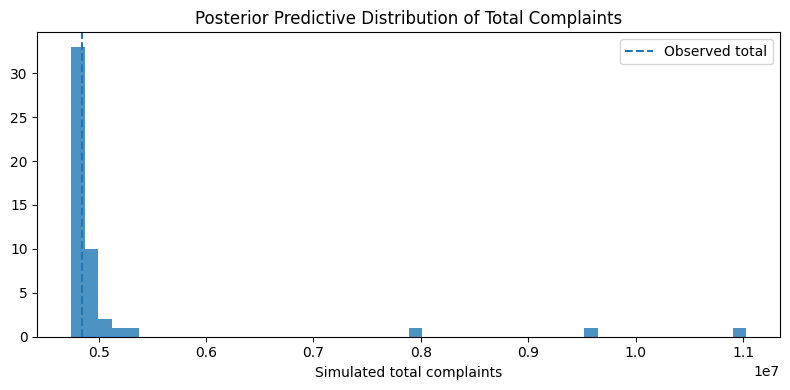

In [23]:
def posterior_predictive_obs_samples(idata, var_name="y_like"):
    arr = idata.posterior_predictive[var_name]
    stacked = arr.stack(sample=("chain", "draw"))
    if "obs" in stacked.dims:
        return stacked.transpose("obs", "sample").values
    obs_dims = [d for d in stacked.dims if d != "sample"]
    if len(obs_dims) != 1:
        raise ValueError(f"Cannot infer obs dimension for {var_name}. Dims: {stacked.dims}")
    return stacked.transpose(obs_dims[0], "sample").values

def synthetic_nb_posterior_predictive(idata, max_samples=50, seed=42):
    """Build yrep from posterior mu and dispersion when y_like is missing.
    Uses NB(mu, alpha) via Poisson-Gamma mixture when dispersion is found.
    Falls back to Poisson(mu) if no dispersion posterior exists.
    Returns (samples, source_label) where samples has shape (obs, sample).
    """
    if "mu" not in idata.posterior.data_vars:
        raise KeyError("posterior 'mu' not found")

    mu = posterior_obs_samples(idata, "mu")  # (obs, sample)
    n_samples = min(mu.shape[1], int(max_samples))
    idx = np.linspace(0, mu.shape[1] - 1, num=n_samples, dtype=int)
    mu_sub = np.clip(mu[:, idx], 1e-12, None)

    # Try common NB overdispersion names across model versions.
    dispersion_candidates = ["alpha_nb", "phi", "alpha", "dispersion"]
    disp_name = next((v for v in dispersion_candidates if v in idata.posterior.data_vars), None)

    rng = np.random.default_rng(seed)
    if disp_name is None:
        yrep = rng.poisson(mu_sub).astype(np.int32)
        return yrep, "synthetic Poisson from posterior mu"

    alpha = idata.posterior[disp_name].stack(sample=("chain", "draw")).values
    alpha_sub = np.clip(alpha[idx], 1e-12, None)
    scale = mu_sub / alpha_sub[None, :]
    lam = rng.gamma(shape=alpha_sub[None, :], scale=scale)
    yrep = rng.poisson(lam).astype(np.int32)
    return yrep, f"synthetic NB from posterior mu + {disp_name}"

if val_df is not None:
    if hasattr(idata, "posterior_predictive") and "y_like" in idata.posterior_predictive:
        yrep_samples = posterior_predictive_obs_samples(idata, "y_like")
        yrep_source = "idata.posterior_predictive['y_like']"
    else:
        yrep_samples, yrep_source = synthetic_nb_posterior_predictive(idata, max_samples=50, seed=42)

    print("yrep source:", yrep_source)
    print("yrep_samples shape:", yrep_samples.shape)

    real_total = val_df["y_obs"].sum()
    simulated_totals = yrep_samples.sum(axis=0)
    print(f"Observed total: {real_total:,.0f}")
    print(f"Posterior predictive total 5/50/95%: {np.percentile(simulated_totals, [5,50,95])}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(simulated_totals, bins=50, alpha=0.8)
    ax.axvline(real_total, linestyle="--", label="Observed total")
    ax.set_title("Posterior Predictive Distribution of Total Complaints")
    ax.set_xlabel("Simulated total complaints")
    ax.legend()
    plt.tight_layout()
else:
    yrep_samples = None
    print("Posterior predictive samples unavailable: val_df missing.")

## 7. Interval calibration

This checks whether uncertainty intervals are honest.

For example, about 80% of observations should fall inside an 80% posterior predictive interval.

Use `y_like` posterior predictive samples when available. If only `mu` is available, the intervals describe uncertainty in the mean, not full predictive uncertainty.

In [24]:
def coverage_table(y_obs, samples, intervals=(0.5, 0.8, 0.9, 0.95)):
    rows = []
    for interval in intervals:
        alpha = 1 - interval
        lo = np.percentile(samples, 100 * alpha / 2, axis=1)
        hi = np.percentile(samples, 100 * (1 - alpha / 2), axis=1)
        inside = (y_obs >= lo) & (y_obs <= hi)
        rows.append({
            "interval": interval,
            "expected_coverage": interval,
            "empirical_coverage": inside.mean(),
            "avg_width": np.mean(hi - lo),
        })
    return pd.DataFrame(rows)

if val_df is not None:
    y_obs = val_df["y_obs"].values
    if yrep_samples is not None:
        calibration = coverage_table(y_obs, yrep_samples)
        print("Posterior predictive interval coverage")
    else:
        calibration = coverage_table(y_obs, mu_samples)
        print("Mean-uncertainty interval coverage only: posterior_predictive['y_like'] not available.")
    display(calibration)
else:
    print("Create val_df first.")

Posterior predictive interval coverage


,interval,expected_coverage,empirical_coverage,avg_width
0,0.50,0.50,0.537178,2.745003
1,0.80,0.80,0.672860,5.429350
2,0.90,0.90,0.716239,9.655556
3,0.95,0.95,0.742913,15.178035


In [25]:
if val_df is not None and cat_col is not None and yrep_samples is not None:
    # Example: 80% predictive interval coverage by category
    lo80 = np.percentile(yrep_samples, 10, axis=1)
    hi80 = np.percentile(yrep_samples, 90, axis=1)
    tmp = val_df.copy()
    tmp["inside_80"] = (tmp["y_obs"] >= lo80) & (tmp["y_obs"] <= hi80)

    coverage_by_cat = (
        tmp.groupby(cat_col, observed=True)
        .agg(n=("y_obs", "size"), coverage_80=("inside_80", "mean"))
        .sort_values("coverage_80")
    )
    display(coverage_by_cat.head(25))
else:
    print("Need val_df, category column, and posterior predictive samples.")

,n,coverage_80
level_2,,
Traffic & Vehicle Noise,9360,0.296795
Heat & Hot Water,9360,0.297650
Parking Issues,9360,0.314744
Aircraft Noise,9360,0.351603
Residential Noise,9360,0.354487
Taxi & For-Hire Vehicles,9360,0.366880
Blocked Access,9360,0.389850
Building Systems,9360,0.408547
Abandoned Vehicles,9360,0.422222


## 8. Baseline comparison

This section compares the Bayesian model against simple alternatives.

Start with baselines that are easy to explain:

1. global mean
2. category mean
3. NTA mean
4. NTA × category historical mean, if available

The Bayesian model is worth using if it improves prediction, calibration, interpretability, or ranking stability.

In [26]:
def score_predictions(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    resid = y_true - y_pred
    return {
        "model": label,
        "MAE": np.mean(np.abs(resid)),
        "RMSE": np.sqrt(np.mean(resid ** 2)),
        "Bias": np.mean(resid),
    }

if val_df is not None:
    scores = []
    y_true = val_df["y_obs"].values

    scores.append(score_predictions(y_true, val_df["mu_mean"].values, "Bayesian pressure model"))
    scores.append(score_predictions(y_true, np.repeat(y_true.mean(), len(y_true)), "Global mean"))

    if cat_col is not None:
        pred_cat_mean = val_df.groupby(cat_col, observed=True)["y_obs"].transform("mean")
        scores.append(score_predictions(y_true, pred_cat_mean.values, "Category mean"))

    if nta_col is not None:
        pred_nta_mean = val_df.groupby(nta_col, observed=True)["y_obs"].transform("mean")
        scores.append(score_predictions(y_true, pred_nta_mean.values, "NTA mean"))

    if nta_col is not None and cat_col is not None:
        pred_nta_cat_mean = val_df.groupby([nta_col, cat_col], observed=True)["y_obs"].transform("mean")
        scores.append(score_predictions(y_true, pred_nta_cat_mean.values, "NTA x category mean"))

    baseline_scores = pd.DataFrame(scores).sort_values("MAE")
    display(baseline_scores)
else:
    print("Create val_df first.")

,model,MAE,RMSE,Bias
4,NTA x category mean,4.409347,40.908496,-8.223874e-18
0,Bayesian pressure model,6.484336,48.066143,-1.903499e-01
2,Category mean,8.747386,50.303117,0.000000e+00
3,NTA mean,10.872277,51.740655,3.575487e-17
1,Global mean,11.982770,52.302661,0.000000e+00


### Holdout validation

The strongest baseline comparison is an out-of-time holdout, for example:

- train on 2020–2024
- test on 2025

If this notebook is only loading one fitted `idata`, use this section after fitting a train-only model and producing predictions for held-out weeks.

In [27]:
# Template for future holdout workflow:
#
# train_df = model_df[model_df[week_col] < "2025-01-01"]
# test_df = model_df[model_df[week_col] >= "2025-01-01"]
#
# 1. fit model on train_df
# 2. call pm.set_data(...) with test inputs
# 3. sample posterior predictive for test rows
# 4. compare against historical mean / simple regression baselines

print("Holdout template added. Implement after your train/test model object is available.")

Holdout template added. Implement after your train/test model object is available.


## 9. Pressure ranking inspection

This is the dashboard sanity check.

Use these tables to inspect whether the highest-pressure areas are credible, explainable, and not just artifacts of reporting bias or data sparsity.

In [28]:
if val_df is not None:
    rank_cols = [c for c in [nta_col, week_col, cat_col, "y_obs", "mu_mean", "pressure_ratio", "log_pressure_ratio", "residual"] if c is not None]

    print("Highest pressure observations: observed much higher than expected")
    display(
        val_df.sort_values("log_pressure_ratio", ascending=False)[rank_cols].head(25)
    )

    print("Lowest pressure observations: observed much lower than expected")
    display(
        val_df.sort_values("log_pressure_ratio", ascending=True)[rank_cols].head(25)
    )
else:
    print("Create val_df first.")

Highest pressure observations: observed much higher than expected


,nta_id,month_start,level_2,y_obs,mu_mean,pressure_ratio,log_pressure_ratio,residual
284391,MN0602,2023-12-01,Micromobility,886.0,0.954641,928.097969,6.117639,885.045359
284451,MN0602,2024-01-01,Micromobility,744.0,1.069873,695.409647,5.885897,742.930127
284331,MN0602,2023-11-01,Micromobility,441.0,0.911894,483.608900,5.443216,440.088106
319351,MN1102,2024-07-01,Disorderly Conduct,170.0,0.234475,725.023470,4.931018,169.765525
420275,QN0802,2023-09-01,Substance Use,1394.0,9.512338,146.546516,4.888100,1384.487662
420155,QN0802,2023-07-01,Substance Use,1257.0,8.847027,142.081627,4.850109,1248.152973
448040,QN1003,2023-04-01,Aircraft Noise,505.0,3.192364,158.189979,4.793272,501.807636
420815,QN0802,2024-06-01,Substance Use,1090.0,8.363777,130.323894,4.758001,1081.636223
420215,QN0802,2023-08-01,Substance Use,1078.0,8.521942,126.496988,4.730191,1069.478058
420875,QN0802,2024-07-01,Substance Use,1193.0,9.605937,124.194021,4.723650,1183.394063


Lowest pressure observations: observed much lower than expected


,nta_id,month_start,level_2,y_obs,mu_mean,pressure_ratio,log_pressure_ratio,residual
419416,QN0802,2022-07-01,Heat & Hot Water,0.0,164.081946,0.000000,-5.106442,-164.081946
419356,QN0802,2022-06-01,Heat & Hot Water,0.0,142.290753,0.000000,-4.964876,-142.290753
420136,QN0802,2023-07-01,Heat & Hot Water,0.0,134.016929,0.000000,-4.905400,-134.016929
420196,QN0802,2023-08-01,Heat & Hot Water,0.0,129.090988,0.000000,-4.868234,-129.090988
397156,QN0602,2024-08-01,Heat & Hot Water,0.0,116.007618,0.000000,-4.762239,-116.007618
279136,MN0502,2022-09-01,Heat & Hot Water,0.0,100.537778,0.000000,-4.620431,-100.537778
261736,MN0202,2022-07-01,Heat & Hot Water,0.0,79.132042,0.000000,-4.383676,-79.132042
253036,MN0101,2022-06-01,Heat & Hot Water,0.0,77.572075,0.000000,-4.364016,-77.572075
358216,QN0202,2024-07-01,Heat & Hot Water,0.0,74.912213,0.000000,-4.329578,-74.912213
544696,SI0302,2022-07-01,Heat & Hot Water,0.0,73.792875,0.000000,-4.314723,-73.792875


In [29]:
if val_df is not None and nta_col is not None:
    dashboard_nta = (
        val_df.groupby(nta_col, observed=True)
        .agg(
            observed_total=("y_obs", "sum"),
            expected_total=("mu_mean", "sum"),
            mean_log_pressure=("log_pressure_ratio", "mean"),
            total_abs_error=("abs_error", "sum"),
        )
        .assign(total_pressure_ratio=lambda d: d["observed_total"] / (d["expected_total"] + 1e-9))
        .sort_values("total_pressure_ratio", ascending=False)
    )
    display(dashboard_nta.head(25))
else:
    print("Need val_df and NTA column.")

,observed_total,expected_total,mean_log_pressure,total_abs_error,total_pressure_ratio
nta_id,,,,,
BX1203,132429.0,55885.087513,-0.880160,123356.282674,2.369666
QN8381,3855.0,2165.920653,-0.313114,5530.054349,1.779844
QN8081,1624.0,993.845181,-0.188315,2536.789060,1.634057
BX0302,18329.0,11968.411397,-0.445608,16093.542961,1.531448
BK0504,21150.0,14739.749364,-0.670033,21959.853521,1.434895
QN1003,20065.0,14029.038704,-0.365057,17427.152019,1.430248
BX0801,32864.0,24674.716765,-0.590022,23868.164333,1.331890
BX0502,41016.0,31709.902977,-0.594589,33381.388750,1.293476
BX0503,30916.0,24153.122474,-0.550069,26536.111887,1.280000


In [30]:
if val_df is not None and nta_col is not None and cat_col is not None:
    dashboard_nta_cat = (
        val_df.groupby([nta_col, cat_col], observed=True)
        .agg(
            observed_total=("y_obs", "sum"),
            expected_total=("mu_mean", "sum"),
            mean_log_pressure=("log_pressure_ratio", "mean"),
        )
        .assign(total_pressure_ratio=lambda d: d["observed_total"] / (d["expected_total"] + 1e-9))
        .sort_values("total_pressure_ratio", ascending=False)
    )
    display(dashboard_nta_cat.head(30))
else:
    print("Need val_df, NTA column, and category column.")

,,observed_total,expected_total,mean_log_pressure,total_pressure_ratio
nta_id,level_2,,,,
QN8492,Recreation Facilities,5.0,0.017129,0.087804,291.896556
BK5691,Recreation Facilities,4.0,0.014567,0.057358,274.597979
QN1491,Wildlife & Other Animal Issues,1.0,0.006314,0.019079,158.387235
SI9592,Recreation Facilities,3.0,0.020149,0.049212,148.890889
SI0391,Bus Stops & Transit Fixtures,8.0,0.059094,0.144402,135.377802
QN8381,Service Complaints,1367.0,12.986078,3.258880,105.266579
QN8081,Service Complaints,627.0,5.957887,2.631507,105.238647
MN0191,Park Rule Violations,101.0,1.066188,0.881358,94.730026
SI9561,Bus Stops & Transit Fixtures,1.0,0.011270,0.018941,88.733314


## 10. Latent state inspection

If the model includes `local_state`, inspect the posterior to understand persistent NTA/category-group pressure changes over time.

This is useful for policy-maker dashboards because it can support claims like:

> This area is not merely noisy week-to-week; it has a sustained upward pressure trend.

In [31]:
if "local_state" in idata.posterior.data_vars:
    local_state_mean = idata.posterior["local_state"].mean(dim=("chain", "draw"))
    print(local_state_mean)

    # Example plot for first few NTA/category-group combinations.
    # Update indexes to inspect specific NTAs and categories.
    try:
        fig, ax = plt.subplots(figsize=(10, 4))
        for nta_i in range(min(3, local_state_mean.sizes.get("nta", 0))):
            for cg_i in range(min(2, local_state_mean.sizes.get("category_group", 0))):
                series = local_state_mean.isel(nta=nta_i, category_group=cg_i).values
                ax.plot(series, alpha=0.8, label=f"nta={nta_i}, group={cg_i}")
        ax.axhline(0, linestyle="--")
        ax.set_title("Example latent local pressure states")
        ax.set_xlabel("Week index")
        ax.set_ylabel("Latent state, log scale")
        ax.legend(fontsize=8)
        plt.tight_layout()
    except Exception as e:
        print("Could not plot local_state:", repr(e))
else:
    print("No local_state variable found in posterior.")

No local_state variable found in posterior.


## 11. Save dashboard-ready validation outputs

These files can feed your dashboard QA layer and presentation tables.

In [32]:
OUT_DIR = Path("../data/processed/model_validation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

if val_df is not None:
    val_df.to_parquet(OUT_DIR / "urban_pressure_validation_rows.parquet", index=False)
    print("Saved:", OUT_DIR / "urban_pressure_validation_rows.parquet")

    if "baseline_scores" in globals():
        baseline_scores.to_csv(OUT_DIR / "baseline_score_comparison.csv", index=False)
        print("Saved:", OUT_DIR / "baseline_score_comparison.csv")

    if "dashboard_nta" in globals():
        dashboard_nta.reset_index().to_csv(OUT_DIR / "dashboard_nta_pressure_summary.csv", index=False)
        print("Saved:", OUT_DIR / "dashboard_nta_pressure_summary.csv")

    if "dashboard_nta_cat" in globals():
        dashboard_nta_cat.reset_index().to_csv(OUT_DIR / "dashboard_nta_category_pressure_summary.csv", index=False)
        print("Saved:", OUT_DIR / "dashboard_nta_category_pressure_summary.csv")
else:
    print("No val_df to save.")

Saved: ../data/processed/model_validation/urban_pressure_validation_rows.parquet
Saved: ../data/processed/model_validation/baseline_score_comparison.csv
Saved: ../data/processed/model_validation/dashboard_nta_pressure_summary.csv
Saved: ../data/processed/model_validation/dashboard_nta_category_pressure_summary.csv


## 12. Validation checklist

Use this as the final notebook conclusion.

### Sampling

- [ ] R-hat is close to 1.00 for key parameters
- [ ] Effective sample size is acceptable
- [ ] Divergences are zero or explained/resolved
- [ ] Trace plots look stable

### Fit

- [ ] Actual vs predicted plot is reasonable
- [ ] Residuals are not dominated by one category or NTA
- [ ] Posterior predictive total counts cover the observed total
- [ ] High-count observations are not systematically underpredicted

### Calibration

- [ ] 50%, 80%, 90%, and 95% intervals have reasonable empirical coverage
- [ ] Coverage is checked by category
- [ ] Coverage is checked by NTA or borough if available

### Baseline comparison

- [ ] Model beats global mean
- [ ] Model beats category mean
- [ ] Model beats NTA mean
- [ ] Ideally model beats NTA × category historical mean on a true holdout

### Dashboard readiness

- [ ] Top pressure rankings are credible
- [ ] Lowest pressure rankings are credible
- [ ] Category drivers are interpretable
- [ ] Uncertainty is exposed, not hidden